# CSCI-544 NLP Final project
# Group36: Jeslyn Yang, Wenwen Han, Ivan Loh, Rachel Lin, Neil Bai
# Detection of AI Generated Text-DetectGPT

In [ ]:
!pip -q install transformers datasets sentencepiece accelerate scikit-learn pandas matplotlib tqdm

In [ ]:
import os
import re
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
)
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers import T5Tokenizer, T5ForConditionalGeneration

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    DEVICE = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

print("DEVICE =", DEVICE)

DEVICE = cuda


## Config

In [ ]:
CFG = {
    "scoring_model_name": "gpt2-large",
    "perturb_model_name": "t5-base",
    "max_length": 256,
    "num_perturbations": 10,
    "mask_ratio": 0.20,
    "span_len": 3,
    "chunk_size_words": 180,
    "chunk_stride_words": 120,
    "min_words": 80,
    "val_count": 100,
    "test_count": 300,
    "threshold_grid_size": 401,
    "essay_csv_path": "/content/Training_Essay_Data.csv",
    "essay_sample_per_class": 200,
}
CFG

{'scoring_model_name': 'gpt2-large',
 'perturb_model_name': 't5-base',
 'max_length': 256,
 'num_perturbations': 10,
 'mask_ratio': 0.2,
 'span_len': 3,
 'chunk_size_words': 180,
 'chunk_stride_words': 120,
 'min_words': 80,
 'val_count': 100,
 'test_count': 300,
 'threshold_grid_size': 401,
 'essay_csv_path': '/content/Training_Essay_Data.csv',
 'essay_sample_per_class': 200}

## Load models

In [ ]:
scoring_tokenizer = AutoTokenizer.from_pretrained(CFG["scoring_model_name"])
if scoring_tokenizer.pad_token is None:
    scoring_tokenizer.pad_token = scoring_tokenizer.eos_token

scoring_model = AutoModelForCausalLM.from_pretrained(CFG["scoring_model_name"]).to(DEVICE)
scoring_model.eval()

perturb_tokenizer = T5Tokenizer.from_pretrained(CFG["perturb_model_name"])
perturb_model = T5ForConditionalGeneration.from_pretrained(CFG["perturb_model_name"]).to(DEVICE)
perturb_model.eval()

print("Loaded scoring model:", CFG["scoring_model_name"])
print("Loaded perturbation model:", CFG["perturb_model_name"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Loaded scoring model: gpt2-large
Loaded perturbation model: t5-base


## Function

In [ ]:
def normalize_text(text: str) -> str:
    text = str(text).strip()
    text = re.sub(r"\s+", " ", text)
    return text

def split_words(text: str):
    return normalize_text(text).split()

def count_words(text: str) -> int:
    return len(split_words(text))

def make_word_chunks(text: str, chunk_size=140, stride=100):
    words = split_words(text)
    if len(words) <= chunk_size:
        return [" ".join(words)]

    chunks = []
    start = 0
    while start < len(words):
        chunk = words[start:start + chunk_size]
        if len(chunk) < max(30, chunk_size // 3):
            break
        chunks.append(" ".join(chunk))
        if start + chunk_size >= len(words):
            break
        start += stride
    return chunks


def pick_main_chunk(text: str, chunk_size=None, stride=None):
    chunk_size = chunk_size or CFG["chunk_size_words"]
    stride = stride or CFG["chunk_stride_words"]
    chunks = make_word_chunks(text, chunk_size=chunk_size, stride=stride)
    chunks = sorted(chunks, key=lambda x: len(split_words(x)), reverse=True)
    return chunks[0]

@torch.no_grad()
def mean_log_probability(text, model, tokenizer, max_length=256):
    text = normalize_text(text)
    enc = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=max_length,
    ).to(DEVICE)

    input_ids = enc["input_ids"]
    attention_mask = enc["attention_mask"]

    outputs = model(input_ids=input_ids, attention_mask=attention_mask)
    logits = outputs.logits[:, :-1, :]
    target_ids = input_ids[:, 1:]
    target_mask = attention_mask[:, 1:]

    log_probs = torch.log_softmax(logits, dim=-1)
    token_log_probs = log_probs.gather(dim=-1, index=target_ids.unsqueeze(-1)).squeeze(-1)
    token_log_probs = token_log_probs * target_mask

    token_count = max(int(target_mask.sum().item()), 1)
    mean_lp = token_log_probs.sum().item() / token_count
    return mean_lp

## Masking perturbations

In [ ]:
def mask_text_spans(text, mask_ratio=0.20, span_len=3):
    words = split_words(text)
    n = len(words)

    if n == 0:
        return text

    n_to_mask = max(1, int(round(mask_ratio * n)))
    spans = []
    covered = set()
    attempts = 0

    while len(covered) < n_to_mask and attempts < n * 10:
        attempts += 1
        start = random.randint(0, max(0, n - 1))
        end = min(n, start + span_len)
        new_positions = [i for i in range(start, end) if i not in covered]
        if not new_positions:
            continue
        spans.append((start, end))
        for i in range(start, end):
            covered.add(i)

    spans = sorted(spans)

    out = []
    cursor = 0
    sentinel_id = 0
    for start, end in spans:
        if start < cursor:
            continue
        out.extend(words[cursor:start])
        out.append(f"<extra_id_{sentinel_id}>")
        cursor = end
        sentinel_id += 1
    out.extend(words[cursor:])

    return " ".join(out)


@torch.no_grad()
def perturb_once(text, mask_ratio=0.20, span_len=3, max_length=256):
    masked_text = mask_text_spans(text, mask_ratio=mask_ratio, span_len=span_len)

    inputs = perturb_tokenizer(
        masked_text,
        return_tensors="pt",
        truncation=True,
        max_length=max_length,
    ).to(DEVICE)

    outputs = perturb_model.generate(
        **inputs,
        max_length=max_length,
        do_sample=True,
        top_p=0.95,
        top_k=50,
        temperature=1.0,
    )

    decoded = perturb_tokenizer.decode(outputs[0], skip_special_tokens=False)

    filled = masked_text
    for i in range(100):
        start_tag = f"<extra_id_{i}>"
        end_tag = f"<extra_id_{i+1}>"

        if start_tag not in decoded:
            break

        start_idx = decoded.find(start_tag) + len(start_tag)
        end_idx = decoded.find(end_tag)

        if end_idx == -1:
            replacement = decoded[start_idx:].strip()
        else:
            replacement = decoded[start_idx:end_idx].strip()

        filled = filled.replace(start_tag, replacement, 1)

    filled = re.sub(r"<extra_id_\\d+>", "", filled)
    filled = normalize_text(filled)

    return filled if filled else normalize_text(text)


def get_perturbations(text, num_perturbations=10, mask_ratio=0.20, span_len=3, max_length=256):
    perturbations = []
    for _ in range(num_perturbations):
        perturbations.append(
            perturb_once(
                text,
                mask_ratio=mask_ratio,
                span_len=span_len,
                max_length=max_length,
            )
        )
    return perturbations

## Score

In [ ]:
@torch.no_grad()
def detectgpt_score(text, num_perturbations=10, mask_ratio=0.20, span_len=3, max_length=256):
    text = normalize_text(text)

    original_logp = mean_log_probability(
        text,
        scoring_model,
        scoring_tokenizer,
        max_length=max_length,
    )

    perturbations = get_perturbations(
        text,
        num_perturbations=num_perturbations,
        mask_ratio=mask_ratio,
        span_len=span_len,
        max_length=max_length,
    )

    perturbed_logps = [
        mean_log_probability(p, scoring_model, scoring_tokenizer, max_length=max_length)
        for p in perturbations
    ]

    mean_perturbed_logp = float(np.mean(perturbed_logps))
    detect_score = original_logp - mean_perturbed_logp

    return {
        "original_logp": float(original_logp),
        "mean_perturbed_logp": float(mean_perturbed_logp),
        "detectgpt_score": float(detect_score),
        "perturbations": perturbations,
        "perturbed_logps": [float(x) for x in perturbed_logps],
    }

## Load dataset

In [ ]:
def find_data():
    candidates = [
        CFG.get("essay_csv_path"),
        "/content/Training_Essay_Data.csv",
        "Training_Essay_Data.csv",
    ]
    for p in candidates:
        if p and os.path.exists(p):
            return p

    try:
        from google.colab import files
        print("CSV not found automatically. Please upload your CSV.")
        uploaded = files.upload()
        for name in uploaded.keys():
            if name.lower().endswith(".csv"):
                return name
    except Exception:
        pass

    raise FileNotFoundError("Could not find the dataset CSV.")


csv_path = find_data()
print("Loading dataset from:", csv_path)

raw_df = pd.read_csv(csv_path)

if "text" not in raw_df.columns:
    raise ValueError("CSV must contain a 'text' column.")

if "generated" in raw_df.columns:
    raw_df["label"] = pd.to_numeric(raw_df["generated"], errors="coerce")
elif "label" in raw_df.columns:
    raw_df["label"] = pd.to_numeric(raw_df["label"], errors="coerce")
else:
    raise ValueError("CSV must contain either 'generated' or 'label'.")

raw_df = raw_df.dropna(subset=["text", "label"]).copy()
raw_df["text"] = raw_df["text"].astype(str).map(normalize_text)
raw_df["label"] = raw_df["label"].astype(int)
raw_df = raw_df[raw_df["label"].isin([0, 1])].copy()

raw_df["word_count"] = raw_df["text"].map(count_words)
data_df = raw_df[raw_df["word_count"] >= CFG["min_words"]].copy()

if CFG["essay_sample_per_class"] is not None:
    sampled_parts = []
    for label_value in [0, 1]:
        part = data_df[data_df["label"] == label_value].copy()
        if len(part) == 0:
            continue
        n_take = min(len(part), CFG["essay_sample_per_class"])
        sampled_parts.append(part.sample(n=n_take, random_state=SEED))
    data_df = pd.concat(sampled_parts, axis=0).sample(frac=1.0, random_state=SEED).reset_index(drop=True)
else:
    data_df = data_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

print("Filtered dataset size:", len(data_df))
print(data_df["label"].value_counts().sort_index())
display(data_df[["text", "label", "word_count"]].head())

Loading dataset from: /content/Training_Essay_Data.csv
Filtered dataset size: 400
label
0    200
1    200
Name: count, dtype: int64


,text,label,word_count
0,"Nowadays, more and more college students rent ...",1,152
1,Going to college is an important step in life....,1,320
2,Imagine it's 1976 and Nasa reveals an interest...,0,489
3,Introduction: Hey there! So you think that the...,1,294
4,Has the face on mars been put there by alien? ...,0,536


## Split validation and test

In [ ]:
VAL_COUNT = CFG["val_count"]
TEST_COUNT = CFG["test_count"]
TOTAL_NEEDED = VAL_COUNT + TEST_COUNT

if len(data_df) < TOTAL_NEEDED:
    raise ValueError(f"Need at least {TOTAL_NEEDED} rows, but only found {len(data_df)}")

if len(data_df) == TOTAL_NEEDED:
    subset_df = data_df.copy()
else:
    subset_df, _ = train_test_split(
        data_df,
        train_size=TOTAL_NEEDED,
        random_state=SEED,
        stratify=data_df["label"] if data_df["label"].nunique() > 1 else None,
    )

val_df, test_df = train_test_split(
    subset_df,
    train_size=VAL_COUNT,
    test_size=TEST_COUNT,
    random_state=SEED,
    stratify=subset_df["label"] if subset_df["label"].nunique() > 1 else None,
)

val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Validation size:", len(val_df))
print("Test size:", len(test_df))

for split_name, split_df in [("val", val_df), ("test", test_df)]:
    print(f"\n{split_name} label counts:")
    print(split_df["label"].value_counts().sort_index())

Validation size: 100
Test size: 300

val label counts:
label
0    50
1    50
Name: count, dtype: int64

test label counts:
label
0    150
1    150
Name: count, dtype: int64


## Score validation and test sets

In [ ]:
def run_detectgpt_on_df(df, split_name="data"):
    rows = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Scoring {split_name}"):
        text = pick_main_chunk(row["text"])
        out = detectgpt_score(
            text,
            num_perturbations=CFG["num_perturbations"],
            mask_ratio=CFG["mask_ratio"],
            span_len=CFG["span_len"],
            max_length=CFG["max_length"],
        )

        rows.append({
            "text": text,
            "label": int(row["label"]),
            "original_logp": out["original_logp"],
            "mean_perturbed_logp": out["mean_perturbed_logp"],
            "detectgpt_score": out["detectgpt_score"],
            **{f"perturbation_{i+1}": p for i, p in enumerate(out["perturbations"])},
        })

    return pd.DataFrame(rows)


val_scores_df = run_detectgpt_on_df(val_df, split_name="val")
test_scores_df = run_detectgpt_on_df(test_df, split_name="test")

Scoring val:   0%|          | 0/100 [00:00<?, ?it/s]

Scoring test:   0%|          | 0/300 [00:00<?, ?it/s]

## Tune threshold on validation

In [ ]:
def tune_threshold(y_true, y_score, grid_size=401, metric="f1"):
    lo, hi = float(np.min(y_score)), float(np.max(y_score))

    if lo == hi:
        pred = np.zeros_like(y_true)
        return lo, "gt", pd.DataFrame([{
            "direction": "gt",
            "threshold": lo,
            "accuracy": accuracy_score(y_true, pred),
            "f1": 0.0,
        }])

    grid = np.linspace(lo, hi, grid_size)
    rows = []

    for direction in ["gt", "lt"]:
        for t in grid:
            pred = (y_score > t).astype(int) if direction == "gt" else (y_score < t).astype(int)
            acc = accuracy_score(y_true, pred)
            prec, rec, f1, _ = precision_recall_fscore_support(
                y_true, pred, average="binary", zero_division=0
            )
            rows.append({
                "direction": direction,
                "threshold": float(t),
                "accuracy": float(acc),
                "precision": float(prec),
                "recall": float(rec),
                "f1": float(f1),
            })

    tune_df = pd.DataFrame(rows)
    best_row = tune_df.sort_values(
        [metric, "accuracy", "precision", "recall"],
        ascending=False
    ).iloc[0]

    return float(best_row["threshold"]), str(best_row["direction"]), tune_df


val_threshold, val_direction, tuning_df = tune_threshold(
    val_scores_df["label"].values,
    val_scores_df["detectgpt_score"].values,
    grid_size=CFG["threshold_grid_size"],
)

print("Selected threshold:", val_threshold)
print("Selected direction:", val_direction)
display(tuning_df.sort_values(["f1", "accuracy"], ascending=False).head(10))

Selected threshold: 0.1386746830072748
Selected direction: gt


,direction,threshold,accuracy,precision,recall,f1
196,gt,0.138675,0.81,0.762712,0.90,0.825688
197,gt,0.139929,0.81,0.762712,0.90,0.825688
195,gt,0.137420,0.80,0.750000,0.90,0.818182
198,gt,0.141183,0.80,0.758621,0.88,0.814815
199,gt,0.142437,0.80,0.758621,0.88,0.814815
200,gt,0.143691,0.80,0.758621,0.88,0.814815
190,gt,0.131150,0.79,0.730159,0.92,0.814159
185,gt,0.124879,0.78,0.705882,0.96,0.813559
186,gt,0.126133,0.78,0.705882,0.96,0.813559
187,gt,0.127387,0.78,0.705882,0.96,0.813559


## Evaluate

In [ ]:
def evaluate_scores(df, threshold, direction="gt"):
    df = df.copy()
    if direction == "gt":
        df["pred"] = (df["detectgpt_score"] > threshold).astype(int)
        auc_scores = df["detectgpt_score"].values
    else:
        df["pred"] = (df["detectgpt_score"] < threshold).astype(int)
        auc_scores = -df["detectgpt_score"].values

    y_true = df["label"].values
    y_pred = df["pred"].values

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )

    try:
        auc = roc_auc_score(y_true, auc_scores)
    except Exception:
        auc = float("nan")

    metrics = {
        "direction": direction,
        "threshold": float(threshold),
        "accuracy": float(acc),
        "precision": float(prec),
        "recall": float(rec),
        "f1": float(f1),
        "auc": float(auc) if not np.isnan(auc) else float("nan"),
    }

    return df, metrics


val_results_df, val_metrics = evaluate_scores(val_scores_df, val_threshold, val_direction)
test_results_df, test_metrics = evaluate_scores(test_scores_df, val_threshold, val_direction)

print("Validation metrics:")
for k, v in val_metrics.items():
    print(f"  {k}: {v}")

print("\\nTest metrics:")
for k, v in test_metrics.items():
    print(f"  {k}: {v}")

Validation metrics:
  direction: gt
  threshold: 0.1386746830072748
  accuracy: 0.81
  precision: 0.7627118644067796
  recall: 0.9
  f1: 0.8256880733944955
  auc: 0.8864000000000001
\nTest metrics:
  direction: gt
  threshold: 0.1386746830072748
  accuracy: 0.8033333333333333
  precision: 0.7630057803468208
  recall: 0.88
  f1: 0.8173374613003096
  auc: 0.8691111111111112


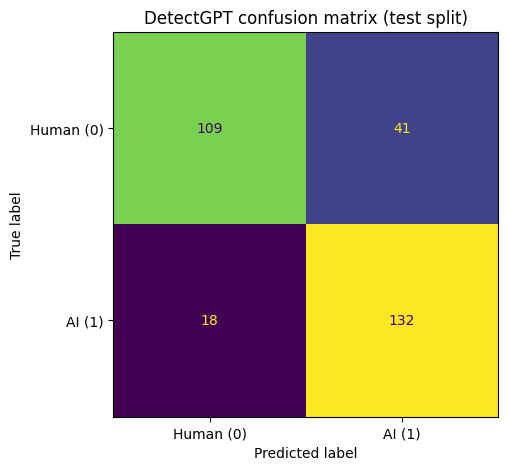

In [ ]:
cm = confusion_matrix(test_results_df["label"].values, test_results_df["pred"].values)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Human (0)", "AI (1)"])
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, colorbar=False)
plt.title("DetectGPT confusion matrix (test split)")
plt.show()

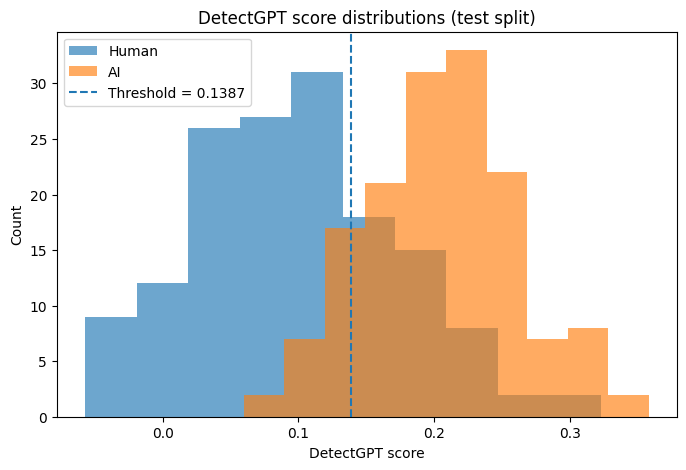

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(test_results_df[test_results_df["label"] == 0]["detectgpt_score"], bins=10, alpha=0.65, label="Human")
plt.hist(test_results_df[test_results_df["label"] == 1]["detectgpt_score"], bins=10, alpha=0.65, label="AI")
plt.axvline(val_threshold, linestyle="--", label=f"Threshold = {val_threshold:.4f}")
plt.xlabel("DetectGPT score")
plt.ylabel("Count")
plt.title("DetectGPT score distributions (test split)")
plt.legend()
plt.show()

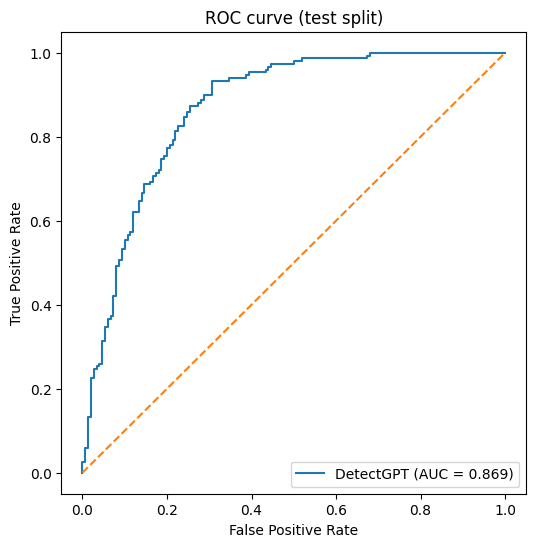

In [ ]:
y_true = test_results_df["label"].values
y_score = test_results_df["detectgpt_score"].values if val_direction == "gt" else -test_results_df["detectgpt_score"].values

fpr, tpr, _ = roc_curve(y_true, y_score)
test_auc = roc_auc_score(y_true, y_score)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"DetectGPT (AUC = {test_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve (test split)")
plt.legend()
plt.show()

In [ ]:
print("Validation threshold selected from validation set only:", val_threshold)
print("Validation direction selected from validation set only:", val_direction)

print("\nValidation sample rows:")
display(val_results_df[["label", "pred", "detectgpt_score", "text"]].head(5))

print("\nTest sample rows:")
display(test_results_df[["label", "pred", "detectgpt_score", "text"]].head(5))

Validation threshold selected from validation set only: 0.1386746830072748
Validation direction selected from validation set only: gt

Validation sample rows:


,label,pred,detectgpt_score,text
0,0,0,0.078619,"""The Face on Mars"" On May 24 2001, a NASA spac..."
1,1,1,0.214053,"Education is an essential part of our lives, a..."
2,0,0,-0.004771,Should drivers be allowed or not allowed to us...
3,1,1,0.276004,There are pros and cons to both sending electr...
4,1,1,0.249383,There is no doubt that computer games are very...



Test sample rows:


,label,pred,detectgpt_score,text
0,1,1,0.212055,It is undeniable that we have become a throw-a...
1,1,1,0.251390,"When you read this statement, how do you think..."
2,1,1,0.199556,Traveling to a foreign country is an experienc...
3,1,1,0.143883,Advantages of Limiting Car Usage Limiting car ...
4,0,0,-0.003548,Limiting car usage is a very good idea. It can...


## Results

In [ ]:
val_results_df.to_csv("detectgpt_val_results.csv", index=False)
test_results_df.to_csv("detectgpt_test_results.csv", index=False)

print("Saved:")
print(" - detectgpt_val_results.csv")
print(" - detectgpt_test_results.csv")

Saved:
 - detectgpt_val_results.csv
 - detectgpt_test_results.csv
